# Advanced usage of `lilypond`

In [1]:
RANDOM_SEED = 42
VERBOSE = False

In [2]:
# load dataset
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True, as_frame=False)
# scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# use helper methods to get SOM hyperparameter recommendations
from minisom_representation import calc_som_hyparams
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=2.0))
print("Recommended SOM parameters:", calc_som_hyparams(X_scaled, initial_sigma_factor=3.0))

Recommended SOM parameters: {'d1': 6, 'd2': 11, 'sigma': np.float64(5.5)}
Recommended SOM parameters: {'d1': 6, 'd2': 11, 'sigma': np.float64(5.5)}
Recommended SOM parameters: {'d1': 6, 'd2': 11, 'sigma': np.float64(3.67)}


In [4]:
# use `factor=3.0` to get a smaller recommendation for sigma -> `sigma=max(d1, d2)/factor)`
from minisom_representation import calc_initial_sigma
sigma = calc_initial_sigma(7, 12, factor=3.0)
print("Sigma:", sigma)

Sigma: 4.0


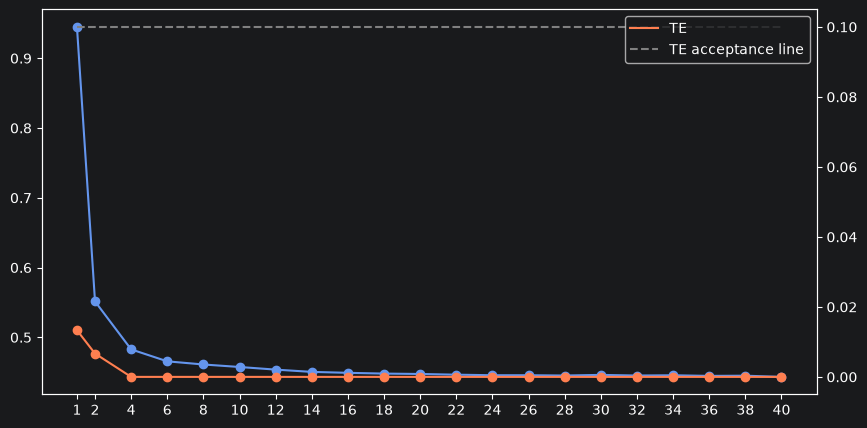


QE (first -> last): 	 0.94 -> 0.44
TE (first -> last): 	 0.01 -> 0.00


In [5]:
# test candidate values for `num_iteration` hyperparameter
from minisom_representation import SomRepresentation, plot_som_convergence_over_epochs
fig, qes, tes = plot_som_convergence_over_epochs(
    SomRepresentation.with_derived_params(X_scaled, random_seed=RANDOM_SEED, verbose=VERBOSE, sigma=sigma),
    X_scaled,
    fit_type="online",
    te_ceiling=.1,
    epoch_step=2,
    epoch_step_from=2,
    epoch_step_to=40,
    figsize=(10, 5),
    show_fig=True,
    verbose=VERBOSE
)
print(f"\nQE (first -> last): \t {qes[0]:.2f} -> {qes[-1]:.2f}")
print(f"TE (first -> last): \t {tes[0]:.2f} -> {tes[-1]:.2f}")

In [14]:
# train an SOM representation
epoch = 40
som_representation = SomRepresentation.with_derived_params(X_scaled, random_seed=RANDOM_SEED, verbose=True, sigma=sigma)
som_representation.fit_online(X_scaled, num_iteration=epoch, use_epochs=True, random_order=True)


--------------
Based on 150 instances, the recommended SOM hyperparameters are the following:
Total node count (M):	 62
Recommended sides (d1 x d2):	 6 x 11
Initial neighborhood radius (sigma):	 5.5
--------------

 [ 6000 / 6000 ] 100% - 0:00:00 left 
 quantization error: 0.4433372928471663

 An SOM representation has been fitted as follows:
------------------------------------------------------- 

Fit strategy: online 

Hyperparameters of SOM: 

{'input_len': 4, 'x': 6, 'y': 11, 'sigma': np.float64(4.0), 'topology': 'rectangular', 'learning_rate': 0.5, 'decay_function': 'asymptotic_decay', 'sigma_decay_function': 'asymptotic_decay', 'neighborhood_function': 'gaussian', 'activation_distance': 'euclidean', 'random_seed': 42, 'num_iteration': 40, 'use_epochs': True, 'random_order': True, 'verbose': True} 

Quality of SOM: 

Quantization Error (QE):	0.4433372928471663
Topographic Error (TE): 	0.0


In [15]:
# use the pre-trained SOM representation
from lilypond import Basin
basin = Basin.from_som_representation(som_representation, random_seed=RANDOM_SEED, verbose=VERBOSE)

In [16]:
basin.pond() \
    .rhizome_layer() \
    .pad_layer() \
    .petal_layer() \
    .visualize();

In [17]:
basin.pond(base_style="iceflock") \
    .rhizome_layer() \
    .pad_layer() \
    .petal_layer() \
    .visualize();

In [18]:
basin.pond() \
    .pad_layer() \
    .attraction_layer(X_scaled) \
    .visualize();

In [19]:
import numpy as np
X_scaled_QE = np.linalg.norm(basin.som_representation.som.quantization(X_scaled) - X_scaled, axis=1)

In [20]:
attraction_marker = dict(opacity=.75, size=10, color=X_scaled_QE, colorscale="Spectral_r", line=dict(width=1, color="black"))
basin.pond() \
    .pad_layer() \
    .attraction_layer(X_scaled, jitter_amount=.3, marker=attraction_marker) \
    .visualize();

In [21]:
basin.pond(base_style="iceflock") \
    .pad_layer() \
    .attraction_layer(X_scaled, jitter_amount=.3, marker=dict(attraction_marker, opacity=.85)) \
    .visualize();